In [23]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import time
import cv2

In [24]:
# target = cv2.imread("./images/ball.jpg")
# source = cv2.imread("./images/water.jpg")
# mask = cv2.imread("./images/mask.png", 0)

target = cv2.imread("./images/corrupted.jpg")
source = cv2.imread("./images/ball.jpg")
mask = cv2.imread("./images/corrupted_mask.png")  #, 0

source = cv2.resize(source, (300, 300))

size = source.shape[:2][::-1]
target = cv2.resize(target, size)
mask = cv2.resize(mask, size)

target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)
source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)


u - градієнт зображення
$$ J(u_x, u_y, u) = \sum_{i=mask_{hmin}}^{mask_{hmax}} \left(\sum_{j=mask_{wmin}}^{mask_{wmin}}\left( \left(u_x(i, j) - v_x(i, j)\right)^2 + \left(u_y(i, j) - v_y(i, j)\right)^2 \right)\right) \rightarrow min $$
$u_{xx}$ - градієнтре поле по х
$$ \frac{\partial{}}{\partial{x}} (2(u_{x} - v_{x})) = 2(u_{xx} - v_{xx}) $$
$$ \frac{\partial{}}{\partial{y}} (2(u_{y} - v_{y})) = 2(u_{yy} - v_{yy}) $$

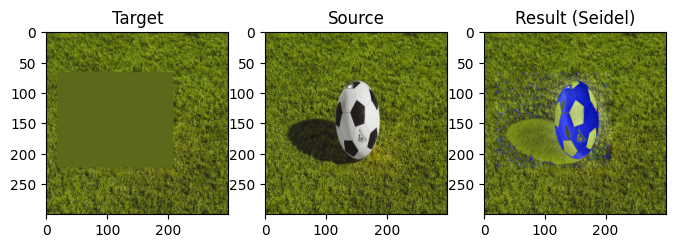

In [25]:
def poisson_seidel(target, source, mask, iterations):
    target = target.astype(float)
    source = source.astype(float)
    h, w, c = target.shape
    m = mask.astype(float) / 255.0
    m = m[:, :, None]
    
    kernel = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])
    laplacian = cv2.filter2D(source, -1, kernel)

    u = target.astype(np.float32)

    kernel_neighbors = np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]], dtype=np.float32)
    for i in range(iterations):
        sum_neighbors = cv2.filter2D(u, -1, kernel_neighbors)

        new_val = (sum_neighbors - laplacian) / 4.0
    
        u = u * (1 - m) + new_val * m

    return (u.astype(np.uint8)).clip(0, 255)
    # return laplacian_source
    
    # # Початкове наближення (можна почати з target або source)
    # f = target.copy()
    
    # # Ітерації
    # # Для прискорення використовуємо зсуви масивів замість циклів по пікселях
    # for k in range(iterations):
    #     # f_new = (f_up + f_down + f_left + f_right - laplacian_source) / 4
    #     # Це оновлення Якобі (паралельне), але для демонстрації збіжності підійде
        
    #     f_up = np.roll(f, 1, axis=0)
    #     f_down = np.roll(f, -1, axis=0)
    #     f_left = np.roll(f, 1, axis=1)
    #     f_right = np.roll(f, -1, axis=1)
        
    #     f_next = (f_up + f_down + f_left + f_right - laplacian_source) / 4.0
        
    #     # Оновлюємо ТІЛЬКИ пікселі всередині маски. Границі (target) залишаються фіксованими (Умова Дирихле)
    #     f = f * (1 - m) + f_next * m
        
    # return np.clip(f, 0, 255).astype(np.uint8)

res_seidel = poisson_seidel(target, source, mask, iterations=500)

plt.figure(figsize=(8, 8))
plt.subplot(131), plt.imshow(target.astype('uint8')), plt.title("Target")
plt.subplot(132), plt.imshow(source.astype('uint8')), plt.title("Source")
plt.subplot(133), plt.imshow(res_seidel), plt.title("Result (Seidel)")
plt.show()


In [26]:
def poisson_scipy(target, source, mask):
    """
    Розв'язує рівняння Пуассона шляхом складання СЛАР Ax=b.
    """
    h, w, num_channels = target.shape
    
    # Знаходимо координати пікселів всередині маски
    # y_idxs, x_idxs - координати пікселів, які ми будемо змінювати (Unknowns)
    # Ми не чіпаємо границі зображення (border), щоб не вийти за межі
    mask_inner = mask[1:-1, 1:-1]
    y_range, x_range = np.where(mask_inner > 128)
    
    # Корекція індексів (бо ми обрізали границі)
    y_range += 1
    x_range += 1
    
    num_pixels = len(y_range)
    if num_pixels == 0:
        return target
        
    # Створюємо мапінг: (y, x) -> index у векторі невідомих
    coord_to_id = -np.ones((h, w), dtype=np.int32)
    coord_to_id[y_range, x_range] = np.arange(num_pixels)
    
    # Створення матриці A (Laplacian Matrix)
    # Рівняння: 4*f(x,y) - f(x-1,y) - f(x+1,y) - f(x,y-1) - f(x,y+1) = Laplacian_Source
    
    # Формуємо розріджену матрицю
    A = sp.lil_matrix((num_pixels, num_pixels), dtype=np.float64)
    b = np.zeros((num_pixels, num_channels), dtype=np.float64)
    
    # Лапласіан джерела
    kernel = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])
    laplacian_source = np.zeros_like(source)
    for ch in range(num_channels):
        laplacian_source[:,:,ch] = cv2.filter2D(source[:,:,ch], -1, kernel)

    # Заповнення матриці A та вектора b
    # Це найдовша частина на Python, тому робимо цикл тільки по пікселях маски
    for i in range(num_pixels):
        y, x = y_range[i], x_range[i]
        
        A[i, i] = 4
        
        # Сусіди: (y-1, x), (y+1, x), (y, x-1), (y, x+1)
        neighbors = [(y-1, x), (y+1, x), (y, x-1), (y, x+1)]
        
        for ny, nx in neighbors:
            if mask[ny, nx] > 128: # Якщо сусід всередині маски - це невідома змінна
                j = coord_to_id[ny, nx]
                A[i, j] = -1
            else: # Якщо сусід на границі (target) - це константа (Boundary Condition), переносимо в b
                b[i] += target[ny, nx]
        
        # Додаємо лапласіан джерела в b
        b[i] += laplacian_source[y, x]

    # Розв'язуємо систему Ax = b
    A_csr = A.tocsr() # Конвертуємо для швидкості
    
    result = target.copy()
    
    # Розв'язуємо для кожного каналу (R, G, B) окремо
    for ch in range(num_channels):
        x_solution = spsolve(A_csr, b[:, ch])
        # Записуємо результат назад у зображення
        result[y_range, x_range, ch] = np.clip(x_solution, 0, 255)
        
    return result.astype(np.uint8)


Seidel Time (sec)    | SciPy Time (sec)    
---------------------------------------------
3.2454               | 0.7039              


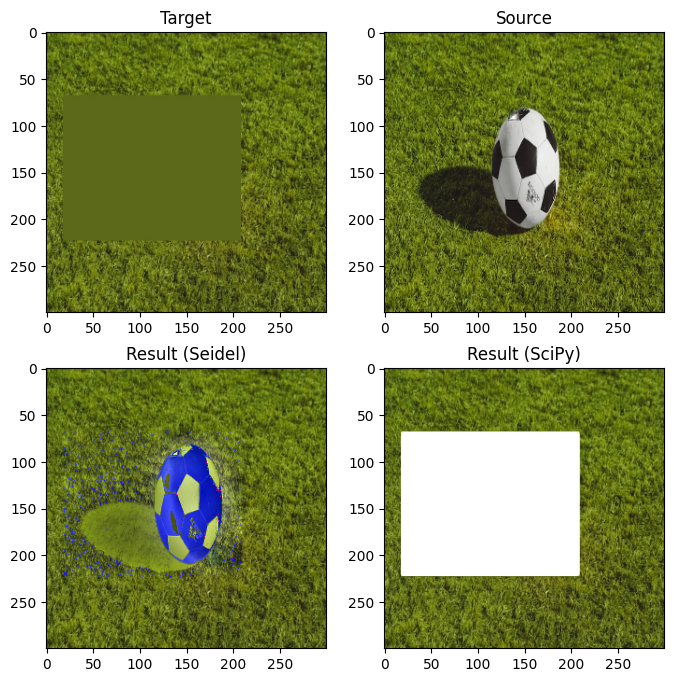

In [27]:

print(f"{'Seidel Time (sec)':<20} | {'SciPy Time (sec)':<20}")
print("-" * 45)

start = time.time()
iterations = 500
res_seidel = poisson_seidel(target, source, mask, iterations=iterations)
end = time.time()
t_seidel = end - start

start = time.time()
res_scipy = poisson_scipy(target, source, mask)
end = time.time()
t_scipy = end - start

print(f"{str(round(t_seidel, 4)):<20} | {str(round(t_scipy, 4)):<20}")

# plt.figure(figsize=(10, 6))
# plt.plot(sizes, times_seidel, marker='o', label='Метод Зейделя (Ітеративний)', color='red')
# plt.plot(sizes, times_scipy, marker='s', label='SciPy Sparse Linalg (Прямий)', color='green')

# plt.title('Порівняння часу виконання: Зейдель vs SciPy')
# plt.xlabel('Розмір зображення (px)')
# plt.ylabel('Час (сек)')
# plt.yscale('log') # Логарифмічна шкала
# plt.grid(True, which="both", ls="-", alpha=0.5)
# plt.legend()

# # Збереження графіка
# plt.savefig('poisson_benchmark.png')
# print("\nГрафік збережено як 'poisson_benchmark.png'")

# Показуємо приклад роботи (для останнього розміру)

plt.figure(figsize=(8, 8))
plt.subplot(221), plt.imshow(target.astype('uint8')), plt.title("Target")
plt.subplot(222), plt.imshow(source.astype('uint8')), plt.title("Source")
plt.subplot(223), plt.imshow(res_seidel), plt.title("Result (Seidel)")
plt.subplot(224), plt.imshow(res_scipy), plt.title("Result (SciPy)")
plt.show()
# plt.savefig('poisson_result_example.png')
# print("Приклад результату збережено як 'poisson_result_example.png'")
